# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1:
### Running a sample script

In [3]:
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score': [52, 55, 60, 65, 70, 75, 78, 82, 87, 92]
}
df = pd.DataFrame(data)

x = df[['hours_studied']]   # DataFrame
y = df['exam_score']        # Series

x_train, x_test, y_train, y_test, = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

print("Model trained sucessfully.")

Model trained sucessfully.


### Working through the sample script

In [4]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.43
Intercept: 47.38


In [5]:
y_pred = model.predict(x_test)
print('Actual scores: ', list(y_test))
print('Predicted scores: ', list(y_pred.round(1)))

Actual scores:  [87, 55]
Predicted scores:  [np.float64(87.3), np.float64(56.2)]


In [6]:
r_squared = model.score(x_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.997


### What does R² mean?

R² (R-squared) measures how much of the variation in exam scores is explained by hours studied. A score of 1.0 means the model perfectly predicts all values. A score of 0 means the model explains none of the variation. For example, an R² of 0.97 means 97% of the variation in exam scores is explained by hours studied, a very strong fit.

C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


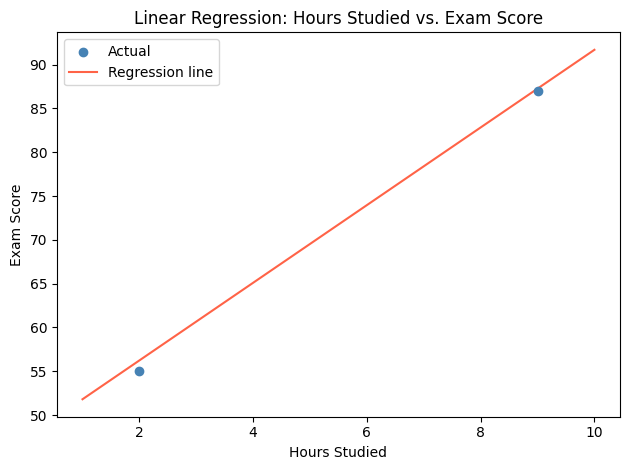

In [7]:
plt.scatter(x_test, y_test, color='steelblue', label='Actual', zorder=3)

x_range = np.linspace(
    x['hours_studied'].min(),
    x['hours_studied'].max(),
    100).reshape(-1, 1)
y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points follow the regression line very closely, with only small deviations. This confirms the high R² score, hours studied is a strong predictor of exam scores in this dataset.

## Lab 2:
### Building your own model

In [8]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue':  [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 12400,
                         13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [9]:
x2 = df_ads[['monthly_ad_spend']] # DataFrame
y2 = df_ads['monthly_revenue'] # Series

print('x2 shape:', x2.shape)
print('y2 shape:', y2.shape)

x2 shape: (20, 1)
y2 shape: (20,)


In [10]:
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=42
)

In [11]:
model2 = LinearRegression()
model2.fit(x2_train, y2_train)
print("Model trained successfully.")

Model trained successfully.


In [12]:
print(f'Slope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')

# For each additional $1 spent on ads, the predicted monthly revenue increases by ~$2.37

Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [13]:
y2_pred = model2.predict(x2_test)

results = pd.DataFrame({
    'Actual Revenue': y2_test.values,
    'Predicted Revenue': y2_pred.round(2)
})
print(results.to_string(index=False))

 Actual Revenue  Predicted Revenue
           4200            4603.85
          21500           21229.03
          19400           19273.13
           5100            5581.80


In [14]:
r2_score = model2.score(x2_test, y2_test)
print(f'R² score: {r2_score:.3f}')

R² score: 0.998


The R² score is very close to 1.0, which means the model explains a very high percentage of the variation in monthly revenue using ad spend alone. This suggests ad spend is a strong linear predictor of revenue — the model appears to be a good fit for this data.

### Visualizing the results

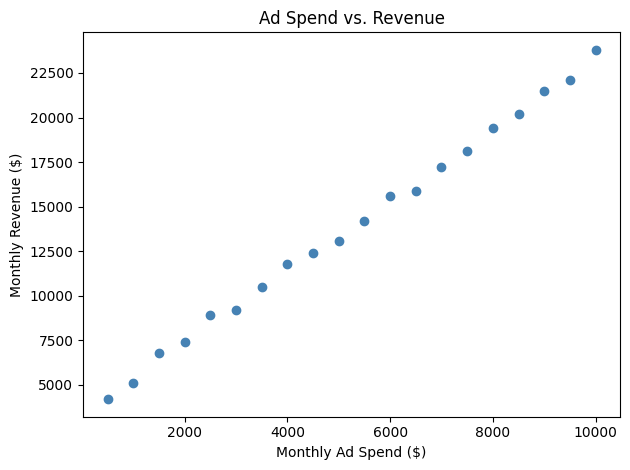

In [16]:
plt.scatter(x2, y2, color='steelblue', label='Actual Data')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


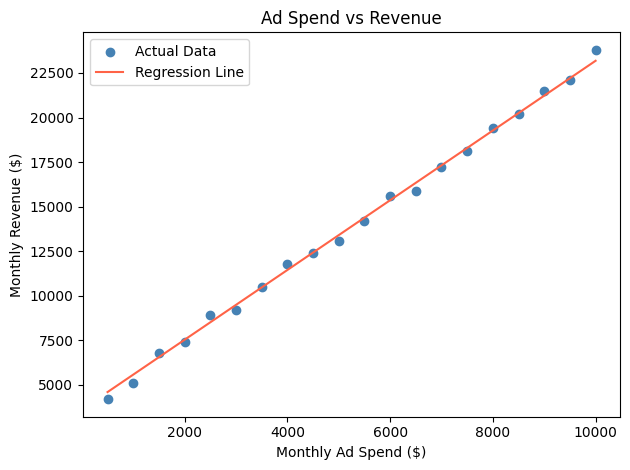

In [17]:
plt.scatter(x2, y2, color='steelblue', label='Actual Data')

# Regression line
x_range2 = np.linspace(x2['monthly_ad_spend'].min(),
                       x2['monthly_ad_spend'].max(),
                       100).reshape(-1, 1)
y_line2 = model2.predict(x_range2)

plt.plot(x_range2, y_line2, color='tomato', label='Regression Line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs Revenue')
plt.legend()
plt.tight_layout()
plt.show()

The regression line fits the scatter plot data very well, the data points track closely along the line from low spend to high spend, with very little spread. This matches the high R² score, confirming the model captures the relationship between ad spend and revenue accurately.